# 06 — Model Training & Evaluation (single XGBoost model, both panels)

**Goal:** predict `PV1_Power_W` and `PV2_Power_W` using **one shared model**.

**Approach:** the data is reshaped so each timestamp appears twice — once for PV1, once for
PV2 — with a `panel` column telling the model which one it is. Since both panels see the same
weather and are highly correlated (~0.99), this lets the model learn the shared weather→power
relationship from **all the data at once** instead of splitting it in half, while the `panel`
feature still lets it express the small but consistent PV1-vs-PV2 gap found earlier.

**Input:** `../Output/checkpoint_05_final.pkl`


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

OUTPUT_DIR = "../Output"
df = pd.read_pickle(f"{OUTPUT_DIR}/checkpoint_05_final.pkl")
print(df.shape)


(5832, 30)


## 1. Build a leakage-free feature set

All electrical readings are excluded — for both panels and the combined total — since they're
outputs measured at the same instant as power itself, not things you'd know in advance.

Redundant weather columns from the correlation analysis are also dropped
(`UV_Index` ≈ `Solar_Radiation_Wm2`, indoor sensors ≈ outdoor equivalents, `AQI_US`/`PM10`/`PM1`
≈ `PM25`, `Wind_Gust_ms` ≈ `Wind_Speed_ms`).


In [2]:
electrical_cols = ["PV1_Power_W", "PV2_Power_W", "PV_Total_Power_W",
                   "PV1_Current_A", "PV2_Current_A", "PV1_Voltage_V", "PV2_Voltage_V"]

redundant_cols = ["UV_Index", "Indoor_Temp_C", "Indoor_Humidity_pct", "Indoor_Pressure_Pa",
                  "AQI_US", "PM10_ugm3", "PM1_ugm3", "Wind_Gust_ms"]

drop_cols = electrical_cols + redundant_cols + ["Timestamp", "PV_imputed"]
base_feature_cols = [c for c in df.columns if c not in drop_cols]
print("Base weather/time features:", base_feature_cols)


Base weather/time features: ['Solar_Radiation_Wm2', 'Outdoor_Temp_C', 'Dew_Point_C', 'Wind_Speed_ms', 'Wind_Dir_deg', 'Pressure_hPa', 'Humidity_pct', 'Rain_mm', 'PM25_ugm3', 'hour', 'month', 'day_of_year', 'is_daylight']


### Cyclical encoding for hour and day-of-year

In [3]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

base_feature_cols = [c for c in base_feature_cols if c not in ["hour", "day_of_year", "month"]] + \
                    ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]
print(f"Feature count: {len(base_feature_cols)}")


Feature count: 14


## 2. Reshape into long format — one row per (timestamp, panel)

Each original row becomes two rows: one for PV1, one for PV2, sharing the same weather
features but with a different `panel` flag and a single unified `Power_W` target column.
This is what lets a single model train on both panels' data at once.

In [4]:
pv1_long = df[["Timestamp"] + base_feature_cols].copy()
pv1_long["panel"] = 0
pv1_long["Power_W"] = df["PV1_Power_W"]

pv2_long = df[["Timestamp"] + base_feature_cols].copy()
pv2_long["panel"] = 1
pv2_long["Power_W"] = df["PV2_Power_W"]

long_df = pd.concat([pv1_long, pv2_long], ignore_index=True).sort_values("Timestamp").reset_index(drop=True)
feature_cols = base_feature_cols + ["panel"]

print(f"Original rows: {len(df)}  ->  Long format rows: {len(long_df)}")
long_df.head()


Original rows: 5832  ->  Long format rows: 11664


,Timestamp,Solar_Radiation_Wm2,Outdoor_Temp_C,Dew_Point_C,Wind_Speed_ms,Wind_Dir_deg,Pressure_hPa,Humidity_pct,Rain_mm,PM25_ugm3,is_daylight,hour_sin,hour_cos,doy_sin,doy_cos,panel,Power_W
0,2026-01-01 00:00:00,0.0,10.192,5.558,0.433,293.500,1015.973,72.833,0.0,10.500,0,0.000000,1.000000,0.017213,0.999852,0,0.0
1,2026-01-01 00:00:00,0.0,10.192,5.558,0.433,293.500,1015.973,72.833,0.0,10.500,0,0.000000,1.000000,0.017213,0.999852,1,0.0
2,2026-01-01 01:00:00,0.0,10.008,5.592,0.333,320.083,1016.199,73.917,0.0,8.433,0,0.258819,0.965926,0.017213,0.999852,1,0.0
3,2026-01-01 01:00:00,0.0,10.008,5.592,0.333,320.083,1016.199,73.917,0.0,8.433,0,0.258819,0.965926,0.017213,0.999852,0,0.0
4,2026-01-01 02:00:00,0.0,9.875,5.808,0.200,321.000,1016.594,75.750,0.0,8.433,0,0.500000,0.866025,0.017213,0.999852,0,0.0


## 3. Chronological train/test split

Split by **timestamp**, not by row — so a given hour's PV1 and PV2 rows always land on the
same side of the split (no leaking one panel's test-period weather into the other panel's
training set).

In [5]:
split_date = df["Timestamp"].quantile(0.8)

train_df = long_df[long_df["Timestamp"] < split_date]
test_df = long_df[long_df["Timestamp"] >= split_date]

print(f"Train: {train_df['Timestamp'].min()} to {train_df['Timestamp'].max()}  ({len(train_df)} rows)")
print(f"Test:  {test_df['Timestamp'].min()} to {test_df['Timestamp'].max()}  ({len(test_df)} rows)")

X_train, y_train = train_df[feature_cols], train_df["Power_W"]
X_test, y_test = test_df[feature_cols], test_df["Power_W"]


Train: 2026-01-01 00:00:00 to 2026-07-14 08:00:00  (9330 rows)
Test:  2026-07-14 09:00:00 to 2026-08-31 23:00:00  (2334 rows)


## 4. Train one shared XGBoost model

In [6]:
xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

model = XGBRegressor(**xgb_params)
model.fit(X_train, y_train)

test_df = test_df.copy()
test_df["pred"] = np.clip(model.predict(X_test), 0, None)

overall_mae = mean_absolute_error(y_test, test_df["pred"])
overall_rmse = np.sqrt(mean_squared_error(y_test, test_df["pred"]))
overall_r2 = r2_score(y_test, test_df["pred"])
print(f"Combined (both panels) — MAE: {overall_mae:.2f}  RMSE: {overall_rmse:.2f}  R2: {overall_r2:.4f}")


Combined (both panels) — MAE: 8.08  RMSE: 18.03  R2: 0.9793


## 5. Evaluate per panel

The model is one object, but we still care about accuracy separately for PV1 vs PV2.

In [7]:
results = {}
for panel_id, name in [(0, "PV1_Power_W"), (1, "PV2_Power_W")]:
    panel_data = test_df[test_df["panel"] == panel_id]
    results[name] = {
        "MAE": mean_absolute_error(panel_data["Power_W"], panel_data["pred"]),
        "RMSE": np.sqrt(mean_squared_error(panel_data["Power_W"], panel_data["pred"])),
        "R2": r2_score(panel_data["Power_W"], panel_data["pred"]),
    }

results_df = pd.DataFrame(results).T
print("Full test set:")
results_df


Full test set:


,MAE,RMSE,R2
PV1_Power_W,8.686129,18.737628,0.978672
PV2_Power_W,7.465008,17.300239,0.980025


### Daylight-only (the metric that reflects real forecasting accuracy)

In [8]:
daylight_results = {}
for panel_id, name in [(0, "PV1_Power_W"), (1, "PV2_Power_W")]:
    panel_daylight = test_df[(test_df["panel"] == panel_id) & (test_df["is_daylight"] == 1)]
    daylight_results[name] = {
        "MAE": mean_absolute_error(panel_daylight["Power_W"], panel_daylight["pred"]),
        "RMSE": np.sqrt(mean_squared_error(panel_daylight["Power_W"], panel_daylight["pred"])),
        "R2": r2_score(panel_daylight["Power_W"], panel_daylight["pred"]),
    }

daylight_results_df = pd.DataFrame(daylight_results).T
daylight_results_df


,MAE,RMSE,R2
PV1_Power_W,13.633410,23.677219,0.966375
PV2_Power_W,11.649539,21.857387,0.967728


## 6. Predictions vs. actual — both panels

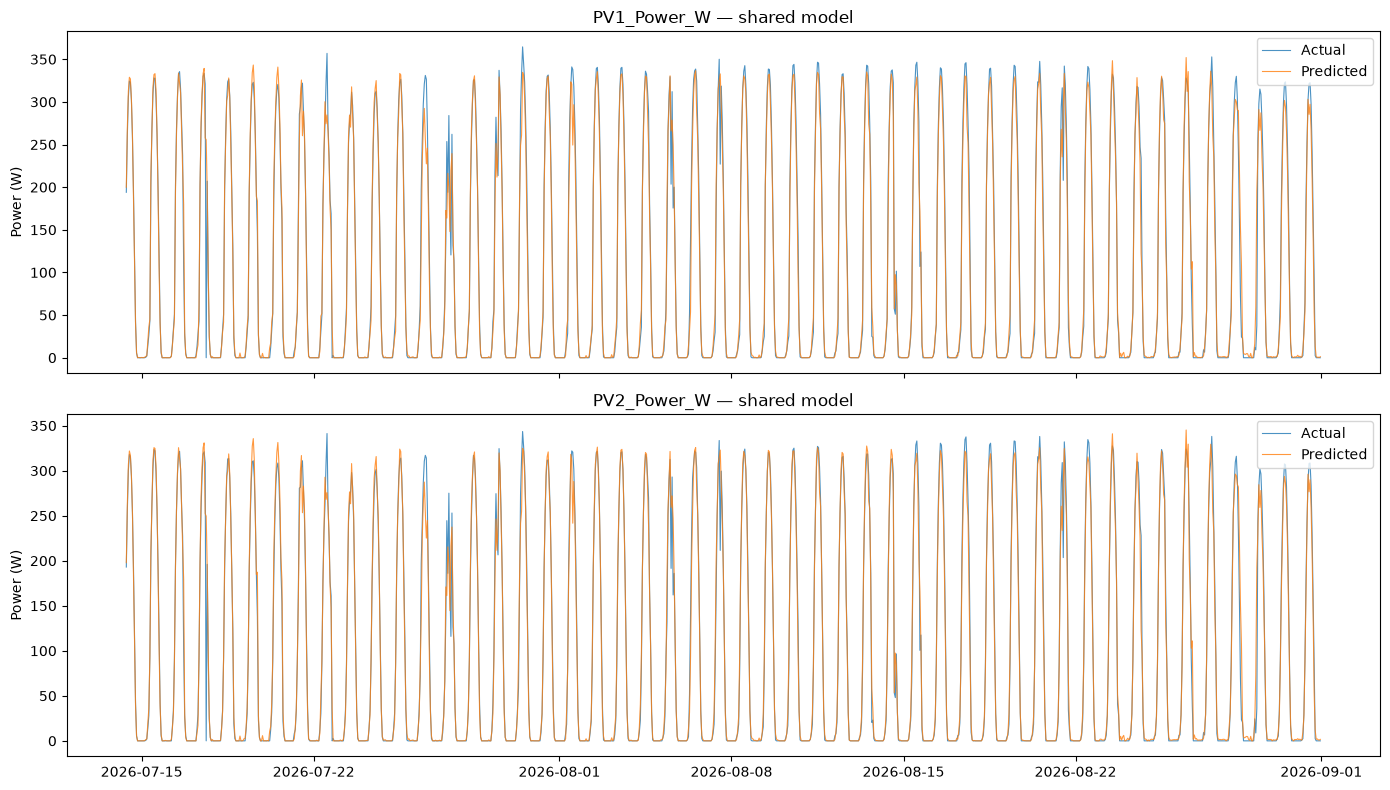

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, panel_id, name in zip(axes, [0, 1], ["PV1_Power_W", "PV2_Power_W"]):
    panel_data = test_df[test_df["panel"] == panel_id]
    ax.plot(panel_data["Timestamp"], panel_data["Power_W"], label="Actual", linewidth=0.8, alpha=0.8)
    ax.plot(panel_data["Timestamp"], panel_data["pred"], label="Predicted", linewidth=0.8, alpha=0.8)
    ax.set_title(f"{name} — shared model")
    ax.set_ylabel("Power (W)")
    ax.legend()

plt.tight_layout()
plt.show()


## 7. Residuals — PV1 vs PV2, from the same model

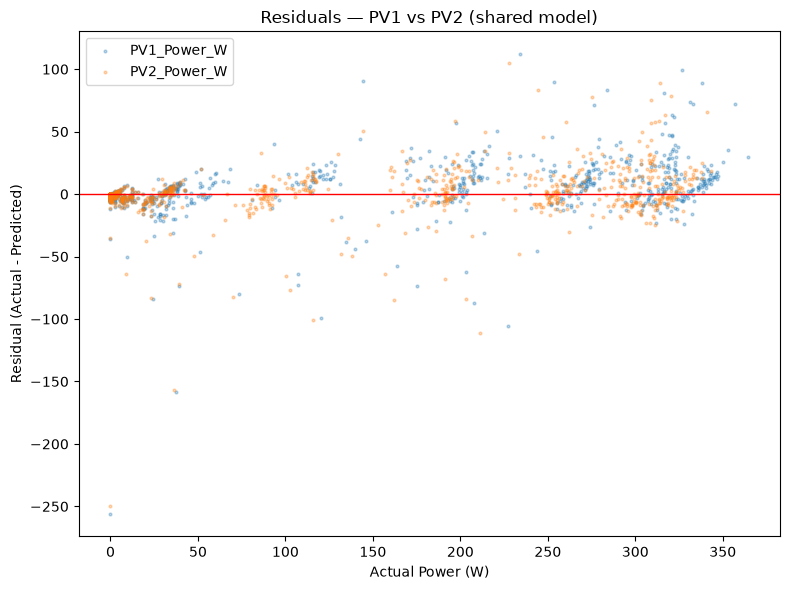

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
for panel_id, name in [(0, "PV1_Power_W"), (1, "PV2_Power_W")]:
    panel_data = test_df[test_df["panel"] == panel_id]
    residuals = panel_data["Power_W"] - panel_data["pred"]
    ax.scatter(panel_data["Power_W"], residuals, s=4, alpha=0.3, label=name)

ax.axhline(0, color="red", linewidth=1)
ax.set_xlabel("Actual Power (W)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residuals — PV1 vs PV2 (shared model)")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Save the model

In [11]:
import joblib
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(model, f"{OUTPUT_DIR}/xgb_shared_model.joblib")
joblib.dump(feature_cols, f"{OUTPUT_DIR}/feature_cols_shared.joblib")
print("Saved shared model and feature list to", OUTPUT_DIR)
print("\nTo predict for a specific panel later: set panel=0 for PV1, panel=1 for PV2 in the input row.")


Saved shared model and feature list to ../Output

To predict for a specific panel later: set panel=0 for PV1, panel=1 for PV2 in the input row.


## Summary

- One XGBoost model trained on both panels' data at once, using a `panel` indicator feature
  instead of two separate models.
- Data was reshaped into long format (one row per timestamp × panel) so the model can pool
  training examples across both panels — useful given the dataset is only ~5,800 hourly rows.
- Chronological split was done by **timestamp** before reshaping, so no hour's data leaks
  across the train/test boundary for either panel.
- `panel`'s feature importance tells you how much the model actually relies on panel identity
  vs. shared weather signal — check this against the PV1-vs-PV2 RMSE gap to see whether the
  model is capturing the physical difference between the panels or mostly ignoring it.

**Next steps:** if this shared model's per-panel accuracy matches the two-separate-models
version, keep this simpler pipeline. If one panel is notably worse here, consider giving the
model an interaction feature (e.g. `panel × hour`) so it can better express panel-specific
timing effects, or add more months of data before deciding this shared model is settled.
